# Temporal Stability of XAI Methods in Fraud Detection

This notebook implements the complete framework for analyzing temporal stability of SHAP and LIME explanations using rolling training windows on credit card fraud data.

## Framework Overview:
1. **Rolling Windows**: Train models on consecutive time windows
2. **Replica Training**: Multiple random seeds to quantify baseline instability
3. **Common Evaluation Slice**: Same future data for fair comparison
4. **Explanation Drift**: Cosine distance, RBO, sign flips
5. **Contextualization**: Data drift, performance changes, drift ratios

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score, log_loss
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import xgboost as xgb
import shap
from lime.lime_tabular import LimeTabularExplainer
from scipy.spatial.distance import cosine
from scipy.stats import wasserstein_distance
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configuration
DATA_PATH = '../CreditCard_Dataset/creditcard.csv'
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load and Prepare Data

In [48]:
df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded successfully. Shape: {df.shape}")
print(f"Time range: {df['Time'].min():.0f} to {df['Time'].max():.0f} seconds")
print(f"Time span: {df['Time'].max() / 3600:.1f} hours")
print(f"Fraud rate: {df['Class'].mean():.4f}")

# Separate features for preprocessing
feature_cols_raw = [col for col in df.columns if col not in ['Time', 'Class']]
print(f"\nFeatures to be standardized: {len(feature_cols_raw)}")
print(f"Feature names: {feature_cols_raw[:10]}...")

df.head()

Dataset loaded successfully. Shape: (284807, 31)
Time range: 0 to 172792 seconds
Time span: 48.0 hours
Fraud rate: 0.0017

Features to be standardized: 29
Feature names: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10']...


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Feature Standardization

**Important**: All features must be standardized to ensure comparable SHAP and LIME explanations. We fit the scaler on each training window and apply it consistently to that window's evaluation data.

In [49]:
# Standardize features
# Note: We'll fit separate scalers for each training window to avoid data leakage
# For now, create a global scaler just to understand the data distribution

feature_cols_raw = [col for col in df.columns if col not in ['Time', 'Class']]

# Create a temporary scaler to show the effect
scaler_temp = StandardScaler()
features_standardized_temp = scaler_temp.fit_transform(df[feature_cols_raw])

print("Feature standardization check:")
print(f"Original features - Mean: {df[feature_cols_raw].mean().mean():.4f}, Std: {df[feature_cols_raw].std().mean():.4f}")
print(f"Standardized features - Mean: {features_standardized_temp.mean():.4f}, Std: {features_standardized_temp.std():.4f}")
print("\nNote: Each training window will have its own scaler fitted to avoid data leakage.")

Feature standardization check:
Original features - Mean: 3.0465, Std: 9.5676
Standardized features - Mean: 0.0000, Std: 1.0000

Note: Each training window will have its own scaler fitted to avoid data leakage.


## 3. Temporal Window Configuration

We'll divide the data into discrete time steps and create rolling training windows. Based on the ~48 hour dataset, we'll use 6-hour time steps.

In [51]:
# Configuration for rolling windows
TIME_STEP_HOURS = 6  # Each time step is 6 hours
WINDOW_LENGTH = 3    # L = 3 time steps (18 hours of training data)
RETRAIN_STEP = 1     # s = 1, retrain every time step
EVAL_HORIZON = 1     # h = 1, evaluate on next 6 hours
NUM_REPLICAS = 5     # R = 5 replicas per model to quantify baseline instability

# Convert to seconds
TIME_STEP_SECONDS = TIME_STEP_HOURS * 3600

# Create time bins
max_time = df['Time'].max()
num_time_steps = int(np.ceil(max_time / TIME_STEP_SECONDS))

print(f"Configuration:")
print(f"  Time step: {TIME_STEP_HOURS} hours ({TIME_STEP_SECONDS} seconds)")
print(f"  Window length L: {WINDOW_LENGTH} time steps ({WINDOW_LENGTH * TIME_STEP_HOURS} hours)")
print(f"  Retrain step s: {RETRAIN_STEP} time step(s)")
print(f"  Evaluation horizon h: {EVAL_HORIZON} time step(s)")
print(f"  Number of replicas R: {NUM_REPLICAS}")
print(f"  Total time steps in dataset: {num_time_steps}")
print(f"  Maximum model pairs: {num_time_steps - WINDOW_LENGTH - RETRAIN_STEP - EVAL_HORIZON + 1}")

Configuration:
  Time step: 6 hours (21600 seconds)
  Window length L: 3 time steps (18 hours)
  Retrain step s: 1 time step(s)
  Evaluation horizon h: 1 time step(s)
  Number of replicas R: 5
  Total time steps in dataset: 8
  Maximum model pairs: 4


Transactions per time step:
           Total_Transactions  Fraud_Count  Fraud_Rate
time_step                                             
0                       12340           55      0.0045
1                       35061           91      0.0026
2                       46850           71      0.0015
3                       50535           64      0.0013
4                       11594           69      0.0060
5                       35851           27      0.0008
6                       49585           63      0.0013
7                       42991           52      0.0012


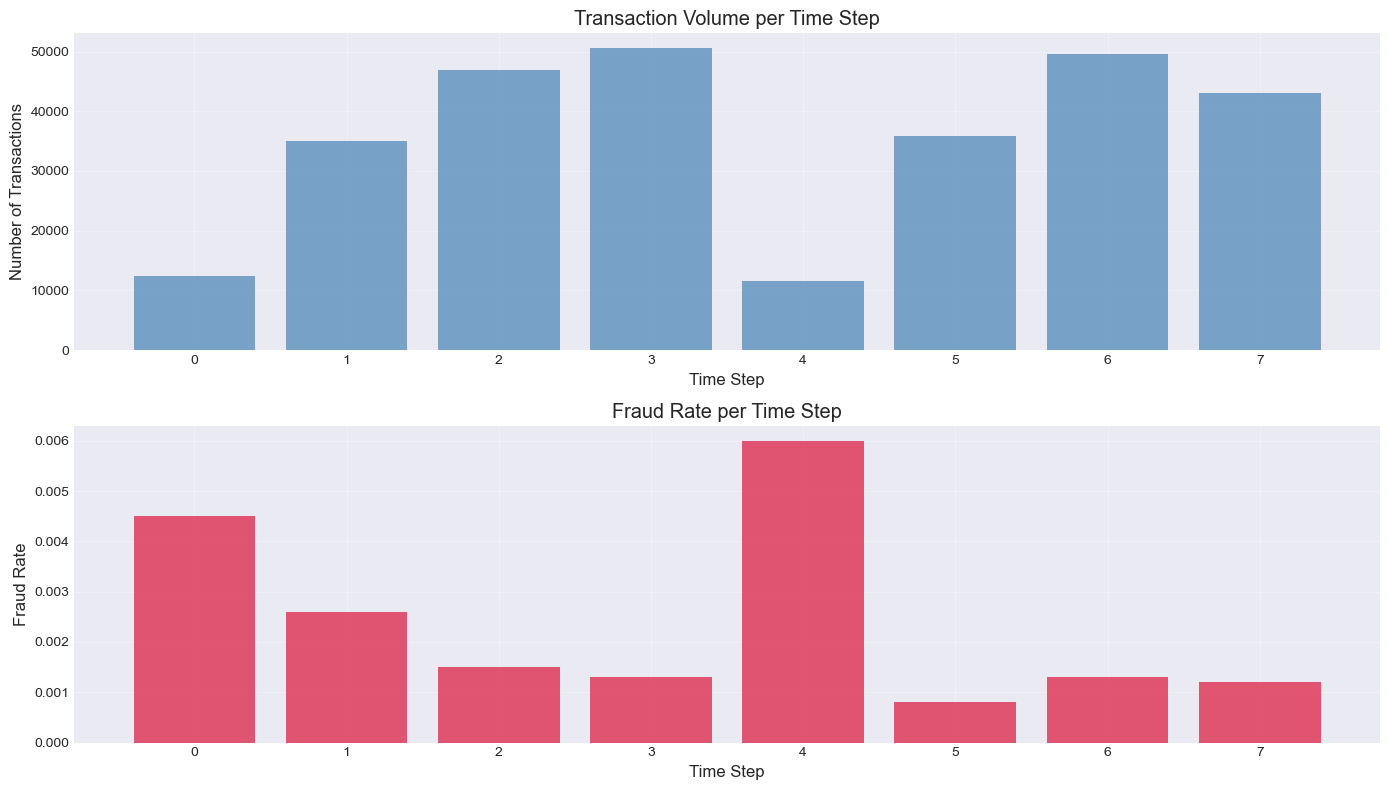

In [52]:
# Assign each transaction to a time step
df['time_step'] = (df['Time'] / TIME_STEP_SECONDS).astype(int)

# Display distribution of transactions across time steps
time_step_counts = df.groupby('time_step').agg({
    'Class': ['count', 'sum', 'mean']
}).round(4)
time_step_counts.columns = ['Total_Transactions', 'Fraud_Count', 'Fraud_Rate']
print("Transactions per time step:")
print(time_step_counts)

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].bar(time_step_counts.index, time_step_counts['Total_Transactions'], alpha=0.7, color='steelblue')
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_title('Transaction Volume per Time Step')
axes[0].grid(True, alpha=0.3)

axes[1].bar(time_step_counts.index, time_step_counts['Fraud_Rate'], alpha=0.7, color='crimson')
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Fraud Rate')
axes[1].set_title('Fraud Rate per Time Step')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Helper Functions for Rolling Windows and Drift Metrics

In [53]:
def train_xgboost_replicas(train_data, num_replicas, feature_cols, target_col='Class'):
    """
    Train multiple XGBoost replicas with different random seeds.
    Returns list of trained models.
    """
    X_train = train_data[feature_cols].values
    y_train = train_data[target_col].values
    
    # Calculate scale_pos_weight for imbalance
    fraud_rate = y_train.mean()
    scale_pos_weight = (1 - fraud_rate) / fraud_rate if fraud_rate > 0 else 1
    
    models = []
    for r in range(num_replicas):
        seed = 42 + r  # Different seed for each replica
        
        model = xgb.XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            scale_pos_weight=scale_pos_weight,
            random_state=seed,
            eval_metric='logloss',
            use_label_encoder=False,
            n_jobs=-1
        )
        
        model.fit(X_train, y_train, verbose=False)
        models.append(model)
    
    return models

def predict_replicas(models, X):
    """Get predictions from all replicas and return averaged predictions."""
    predictions = np.array([model.predict_proba(X)[:, 1] for model in models])
    return predictions.mean(axis=0)

print("Model training functions defined!")

Model training functions defined!


## 5. Model Training with Time-Series Cross-Validation and Hyperparameter Tuning

Each model is trained with:
1. **TimeSeriesSplit** cross-validation to prevent temporal leakage
2. **Hyperparameter tuning** using GridSearchCV
3. **Multiple replicas** with different random seeds for baseline instability quantification

In [54]:
def tune_hyperparameters(X_train, y_train, random_state=42):
    """
    Tune XGBoost hyperparameters using TimeSeriesSplit cross-validation.
    Returns best parameters.
    """
    # Calculate scale_pos_weight for imbalance
    fraud_rate = y_train.mean()
    scale_pos_weight = (1 - fraud_rate) / fraud_rate if fraud_rate > 0 else 1
    
    # Define parameter grid
    param_grid = {
        'n_estimators': [50, 100, 150],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }
    
    # Base model
    base_model = xgb.XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=random_state,
        eval_metric='logloss',
        use_label_encoder=False,
        n_jobs=-1
    )
    
    # TimeSeriesSplit for temporal cross-validation
    tscv = TimeSeriesSplit(n_splits=3)
    
    # GridSearchCV
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=tscv,
        scoring='average_precision',  # PR-AUC
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X_train, y_train)
    
    return grid_search.best_params_, grid_search.best_score_

def train_xgboost_replicas(train_data, num_replicas, feature_cols, target_col='Class'):
    """
    Train multiple XGBoost replicas with different random seeds.
    Uses hyperparameter tuning with TimeSeriesSplit for each replica.
    Returns list of trained models, scaler, and best hyperparameters.
    """
    # Separate features and target
    X_train_raw = train_data[feature_cols].values
    y_train = train_data[target_col].values
    
    # Fit scaler on training data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    
    # Calculate scale_pos_weight for imbalance
    fraud_rate = y_train.mean()
    scale_pos_weight = (1 - fraud_rate) / fraud_rate if fraud_rate > 0 else 1
    
    # Tune hyperparameters once (using first replica's seed)
    print(f"  Tuning hyperparameters with TimeSeriesSplit CV...")
    best_params, best_score = tune_hyperparameters(X_train, y_train, random_state=42)
    print(f"  Best CV score (PR-AUC): {best_score:.4f}")
    print(f"  Best params: {best_params}")
    
    # Train replicas with tuned hyperparameters but different random seeds
    models = []
    for r in range(num_replicas):
        seed = 42 + r  # Different seed for each replica
        
        model = xgb.XGBClassifier(
            **best_params,
            scale_pos_weight=scale_pos_weight,
            random_state=seed,
            eval_metric='logloss',
            use_label_encoder=False,
            n_jobs=-1
        )
        
        model.fit(X_train, y_train, verbose=False)
        models.append(model)
    
    return models, scaler, best_params

def predict_replicas(models, X):
    """Get predictions from all replicas and return averaged predictions."""
    predictions = np.array([model.predict_proba(X)[:, 1] for model in models])
    return predictions.mean(axis=0)

def get_fraud_predictions(models, X, threshold=0.5):
    """
    Get fraud predictions from replicas.
    Returns boolean array indicating which instances are predicted as fraud.
    """
    avg_predictions = predict_replicas(models, X)
    return avg_predictions >= threshold

print("Model training functions with hyperparameter tuning defined!")

Model training functions with hyperparameter tuning defined!


## 6. Explanation Generation (SHAP and LIME) - Fraud-Flagged Transactions Only

**Important**: Fraud investigators only examine explanations for transactions flagged as fraud. We compute explanations only for instances predicted as fraud by either Model A or Model B.

In [55]:
def compute_shap_attributions(models, X, feature_cols):
    """
    Compute SHAP attributions for all replicas and return averaged attributions.
    Uses TreeExplainer for XGBoost models.
    X should already be standardized.
    """
    all_shap_values = []
    
    for model in models:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X)
        all_shap_values.append(shap_values)
    
    # Average across replicas
    avg_shap_values = np.mean(all_shap_values, axis=0)
    return avg_shap_values, all_shap_values

def compute_lime_attributions(models, X_train, X_test, feature_cols, num_samples=1000):
    """
    Compute LIME attributions for all replicas and return averaged attributions.
    Both X_train and X_test should already be standardized.
    Note: LIME is computed per instance, so this returns a matrix.
    """
    # Create LIME explainer using training data
    explainer = LimeTabularExplainer(
        X_train,
        feature_names=feature_cols,
        class_names=['Legitimate', 'Fraud'],
        mode='classification',
        random_state=42
    )
    
    all_lime_values = []
    
    for model in models:
        lime_values = []
        
        # For each instance in test set
        for i in range(len(X_test)):
            # Get explanation
            exp = explainer.explain_instance(
                X_test[i],
                model.predict_proba,
                num_features=len(feature_cols),
                num_samples=num_samples
            )
            
            # Extract feature attributions in correct order
            exp_dict = dict(exp.as_list())
            attributions = np.zeros(len(feature_cols))
            
            for j, feat_name in enumerate(feature_cols):
                # LIME returns feature names, need to match them
                for key in exp_dict.keys():
                    if feat_name in key or key in feat_name:
                        attributions[j] = exp_dict[key]
                        break
            
            lime_values.append(attributions)
        
        all_lime_values.append(np.array(lime_values))
    
    # Average across replicas
    avg_lime_values = np.mean(all_lime_values, axis=0)
    return avg_lime_values, all_lime_values

print("Explanation functions defined!")

Explanation functions defined!


## 7. Data Drift Metrics

In [56]:
def compute_covariate_drift(data_a, data_b, feature_cols):
    """
    Compute covariate drift using average Wasserstein distance across features.
    """
    wasserstein_distances = []
    
    for col in feature_cols:
        wd = wasserstein_distance(data_a[col].values, data_b[col].values)
        wasserstein_distances.append(wd)
    
    # Return mean Wasserstein distance
    return np.mean(wasserstein_distances)

def compute_target_drift(data_a, data_b, target_col='Class'):
    """
    Compute target drift as absolute difference in fraud rates.
    """
    fraud_rate_a = data_a[target_col].mean()
    fraud_rate_b = data_b[target_col].mean()
    return abs(fraud_rate_a - fraud_rate_b)

def compute_performance_change(models_a, models_b, scaler_a, scaler_b, 
                               eval_data, feature_cols, target_col='Class'):
    """
    Compute performance change between model A and B on evaluation slice.
    Returns delta_perf = Loss(A) - Loss(B), where positive means B is better.
    Uses 1 - PR-AUC as loss.
    """
    X_eval_raw = eval_data[feature_cols].values
    y_eval = eval_data[target_col].values
    
    # Standardize using respective scalers
    X_eval_a = scaler_a.transform(X_eval_raw)
    X_eval_b = scaler_b.transform(X_eval_raw)
    
    # Get averaged predictions
    pred_a = predict_replicas(models_a, X_eval_a)
    pred_b = predict_replicas(models_b, X_eval_b)
    
    # Compute PR-AUC for both
    precision_a, recall_a, _ = precision_recall_curve(y_eval, pred_a)
    pr_auc_a = auc(recall_a, precision_a)
    
    precision_b, recall_b, _ = precision_recall_curve(y_eval, pred_b)
    pr_auc_b = auc(recall_b, precision_b)
    
    # Loss = 1 - PR-AUC (lower is better)
    loss_a = 1 - pr_auc_a
    loss_b = 1 - pr_auc_b
    
    delta_perf = loss_a - loss_b  # Positive if B is better
    
    return delta_perf, pr_auc_a, pr_auc_b

print("Data drift functions defined!")

Data drift functions defined!


## 8. Explanation Drift Metrics

In [ ]:
def compute_local_drift_metrics(attr_a_avg, attr_b_avg, attr_a_all, attr_b_all, top_m=5):
    """
    Compute local explanation drift metrics for a single instance.
    
    Parameters:
    - attr_a_avg, attr_b_avg: Averaged attributions across replicas
    - attr_a_all, attr_b_all: List of attributions from all replicas (for baseline)
    - top_m: Number of top features for sign flip analysis
    
    Returns dict with cosine distance, RBO distance, and sign flip fraction.
    """
    # Cosine distance between averaged attributions
    cos_dist = cosine_distance(attr_a_avg, attr_b_avg)
    
    # Rank-based drift (RBO)
    rank_a = rank_features_by_magnitude(attr_a_avg)
    rank_b = rank_features_by_magnitude(attr_b_avg)
    rbo_similarity = compute_rbo(rank_a, rank_b, p=0.9)
    rbo_dist = 1 - rbo_similarity
    
    # Sign flips among top features
    sign_flip_frac = compute_sign_flips(attr_a_avg, attr_b_avg, top_m=top_m)
    
    return {
        'cosine_distance': cos_dist,
        'rbo_distance': rbo_dist,
        'sign_flip_fraction': sign_flip_frac
    }

def compute_baseline_instability(attr_all_replicas):
    """
    Compute baseline instability for a single instance across replicas.
    Returns median pairwise distance across all replica pairs.
    """
    num_replicas = len(attr_all_replicas)
    
    # Compute pairwise distances
    cos_distances = []
    rbo_distances = []
    
    for r1, r2 in combinations(range(num_replicas), 2):
        attr_r1 = attr_all_replicas[r1]
        attr_r2 = attr_all_replicas[r2]
        
        # Cosine distance
        cos_dist = cosine_distance(attr_r1, attr_r2)
        cos_distances.append(cos_dist)
        
        # RBO distance
        rank_r1 = rank_features_by_magnitude(attr_r1)
        rank_r2 = rank_features_by_magnitude(attr_r2)
        rbo_sim = compute_rbo(rank_r1, rank_r2, p=0.9)
        rbo_distances.append(1 - rbo_sim)
    
    return {
        'cosine_baseline': np.median(cos_distances),
        'rbo_baseline': np.median(rbo_distances)
    }

def compute_global_drift_shap(shap_a_avg, shap_b_avg):
    """
    Compute global drift for SHAP by comparing feature importance rankings.
    
    Parameters:
    - shap_a_avg, shap_b_avg: Arrays of shape (n_instances, n_features)
    
    Returns global drift based on RBO of feature importance rankings.
    """
    # Compute global importance: mean absolute SHAP value per feature
    global_importance_a = np.mean(np.abs(shap_a_avg), axis=0)
    global_importance_b = np.mean(np.abs(shap_b_avg), axis=0)
    
    # Rank features by importance
    rank_a = np.argsort(-global_importance_a)
    rank_b = np.argsort(-global_importance_b)
    
    # Compute RBO
    rbo_sim = compute_rbo(rank_a, rank_b, p=0.9)
    global_drift = 1 - rbo_sim
    
    return global_drift, global_importance_a, global_importance_b

print("Explanation drift functions defined!")

Main experiment function defined!


## 9. Main Experiment Loop

This is the core implementation that:
1. Iterates through all valid window pairs (A, B)
2. Trains replicas for each model version with **hyperparameter tuning** and **TimeSeriesSplit CV**
3. **Standardizes features** using scalers fitted on each training window
4. Identifies **fraud-flagged transactions** (predicted as fraud by either model A or B)
5. Computes explanations (SHAP and LIME) **only for flagged transactions**
6. Calculates all drift metrics, baseline instability, and drift ratios

In [58]:
def run_temporal_stability_experiment(df, feature_cols, window_length, retrain_step, 
                                      eval_horizon, num_replicas, max_pairs=None,
                                      use_shap=True, use_lime=False, fraud_threshold=0.5):
    """
    Main experiment loop for temporal stability analysis.
    
    Parameters:
    - df: DataFrame with 'time_step' column
    - feature_cols: List of feature column names
    - window_length: L (number of time steps in training window)
    - retrain_step: s (retrain every s time steps)
    - eval_horizon: h (evaluation horizon in time steps)
    - num_replicas: R (number of replicas per model)
    - max_pairs: Maximum number of model pairs to evaluate (None = all)
    - use_shap: Whether to compute SHAP explanations
    - use_lime: Whether to compute LIME explanations (slower)
    - fraud_threshold: Threshold for flagging transactions as fraud
    
    Returns: DataFrame with all metrics for each model pair
    """
    results = []
    
    # Determine valid window pairs
    max_time_step = df['time_step'].max()
    valid_pairs = []
    
    k = window_length - 1  # First valid end step for window A
    while True:
        # Window A ends at step k
        # Window B ends at step k + retrain_step
        k_b = k + retrain_step
        
        # Evaluation slice starts after k_b and spans eval_horizon steps
        eval_end = k_b + eval_horizon
        
        if eval_end > max_time_step:
            break
        
        valid_pairs.append((k, k_b))
        k += retrain_step
    
    if max_pairs is not None:
        valid_pairs = valid_pairs[:max_pairs]
    
    print(f"Found {len(valid_pairs)} valid model pairs to evaluate")
    print(f"Window length: {window_length} steps, Retrain step: {retrain_step}, Eval horizon: {eval_horizon}")
    print(f"Number of replicas: {num_replicas}")
    print(f"Fraud threshold: {fraud_threshold}")
    print(f"Computing SHAP: {use_shap}, Computing LIME: {use_lime}\n")
    
    # Process each pair
    for pair_idx, (k_a, k_b) in enumerate(valid_pairs):
        print(f"\n{'='*80}")
        print(f"Processing pair {pair_idx + 1}/{len(valid_pairs)}: Window A ends at t={k_a}, Window B ends at t={k_b}")
        print(f"{'='*80}")
        
        # Get training windows
        window_a = get_window_data(df, k_a, window_length)
        window_b = get_window_data(df, k_b, window_length)
        
        # Get common evaluation slice
        eval_slice = get_eval_slice(df, k_b, eval_horizon)
        
        print(f"Window A: {len(window_a)} transactions (steps {k_a - window_length + 1} to {k_a})")
        print(f"  Fraud rate: {window_a['Class'].mean():.4f}")
        print(f"Window B: {len(window_b)} transactions (steps {k_b - window_length + 1} to {k_b})")
        print(f"  Fraud rate: {window_b['Class'].mean():.4f}")
        print(f"Eval slice: {len(eval_slice)} transactions (steps {k_b + 1} to {k_b + eval_horizon})")
        print(f"  Fraud rate: {eval_slice['Class'].mean():.4f}")
        
        if len(eval_slice) == 0:
            print("Warning: Empty evaluation slice, skipping this pair")
            continue
        
        # Train replicas for both models (includes standardization and hyperparameter tuning)
        print(f"\nTraining {num_replicas} replicas for Model A with hyperparameter tuning...")
        models_a, scaler_a, best_params_a = train_xgboost_replicas(window_a, num_replicas, feature_cols)
        
        print(f"\nTraining {num_replicas} replicas for Model B with hyperparameter tuning...")
        models_b, scaler_b, best_params_b = train_xgboost_replicas(window_b, num_replicas, feature_cols)
        
        # Prepare evaluation data (raw features)
        X_eval_raw = eval_slice[feature_cols].values
        
        # Standardize using respective scalers
        X_eval_a = scaler_a.transform(X_eval_raw)
        X_eval_b = scaler_b.transform(X_eval_raw)
        
        # Identify fraud-flagged transactions (predicted as fraud by either model)
        print("\nIdentifying fraud-flagged transactions...")
        flagged_a = get_fraud_predictions(models_a, X_eval_a, threshold=fraud_threshold)
        flagged_b = get_fraud_predictions(models_b, X_eval_b, threshold=fraud_threshold)
        flagged_union = flagged_a | flagged_b  # Union: flagged by either model
        
        num_flagged = flagged_union.sum()
        print(f"  Model A flagged: {flagged_a.sum()} transactions")
        print(f"  Model B flagged: {flagged_b.sum()} transactions")
        print(f"  Union (either model): {num_flagged} transactions ({num_flagged/len(eval_slice)*100:.2f}%)")
        
        if num_flagged == 0:
            print("Warning: No transactions flagged as fraud, skipping explanation analysis")
            # Still compute data drift and performance
            covariate_drift = compute_covariate_drift(window_a, window_b, feature_cols)
            target_drift = compute_target_drift(window_a, window_b)
            delta_perf, pr_auc_a, pr_auc_b = compute_performance_change(
                models_a, models_b, scaler_a, scaler_b, eval_slice, feature_cols
            )
            
            result = {
                'pair_idx': pair_idx,
                'window_a_end': k_a,
                'window_b_end': k_b,
                'eval_size': len(eval_slice),
                'num_flagged': 0,
                'covariate_drift': covariate_drift,
                'target_drift': target_drift,
                'pr_auc_a': pr_auc_a,
                'pr_auc_b': pr_auc_b,
                'delta_perf': delta_perf
            }
            results.append(result)
            continue
        
        # Filter to flagged transactions only
        X_eval_a_flagged = X_eval_a[flagged_union]
        X_eval_b_flagged = X_eval_b[flagged_union]
        
        # Compute data drift
        print("\nComputing data drift metrics...")
        covariate_drift = compute_covariate_drift(window_a, window_b, feature_cols)
        target_drift = compute_target_drift(window_a, window_b)
        
        # Compute performance change
        print("Computing performance metrics...")
        delta_perf, pr_auc_a, pr_auc_b = compute_performance_change(
            models_a, models_b, scaler_a, scaler_b, eval_slice, feature_cols
        )
        
        result = {
            'pair_idx': pair_idx,
            'window_a_end': k_a,
            'window_b_end': k_b,
            'eval_size': len(eval_slice),
            'num_flagged': num_flagged,
            'pct_flagged': num_flagged / len(eval_slice) * 100,
            'covariate_drift': covariate_drift,
            'target_drift': target_drift,
            'pr_auc_a': pr_auc_a,
            'pr_auc_b': pr_auc_b,
            'delta_perf': delta_perf,
            'best_params_a': str(best_params_a),
            'best_params_b': str(best_params_b)
        }
        
        # SHAP analysis (only on flagged transactions)
        if use_shap:
            print(f"\nComputing SHAP explanations for {num_flagged} flagged transactions...")
            shap_a_avg, shap_a_all = compute_shap_attributions(models_a, X_eval_a_flagged, feature_cols)
            shap_b_avg, shap_b_all = compute_shap_attributions(models_b, X_eval_b_flagged, feature_cols)
            
            # Local drift metrics for each flagged instance
            local_cos_dists = []
            local_rbo_dists = []
            local_sign_flips = []
            baseline_cos_a = []
            baseline_rbo_a = []
            baseline_cos_b = []
            baseline_rbo_b = []
            
            print(f"Computing local drift for {num_flagged} flagged instances...")
            for i in range(num_flagged):
                # Temporal drift
                drift_metrics = compute_local_drift_metrics(
                    shap_a_avg[i], shap_b_avg[i],
                    [shap_a_all[r][i] for r in range(num_replicas)],
                    [shap_b_all[r][i] for r in range(num_replicas)]
                )
                local_cos_dists.append(drift_metrics['cosine_distance'])
                local_rbo_dists.append(drift_metrics['rbo_distance'])
                local_sign_flips.append(drift_metrics['sign_flip_fraction'])
                
                # Baseline instability for A
                baseline_a = compute_baseline_instability(
                    [shap_a_all[r][i] for r in range(num_replicas)]
                )
                baseline_cos_a.append(baseline_a['cosine_baseline'])
                baseline_rbo_a.append(baseline_a['rbo_baseline'])
                
                # Baseline instability for B
                baseline_b = compute_baseline_instability(
                    [shap_b_all[r][i] for r in range(num_replicas)]
                )
                baseline_cos_b.append(baseline_b['cosine_baseline'])
                baseline_rbo_b.append(baseline_b['rbo_baseline'])
            
            # Aggregate with median
            result['shap_local_cos_drift'] = np.median(local_cos_dists)
            result['shap_local_rbo_drift'] = np.median(local_rbo_dists)
            result['shap_sign_flip_median'] = np.median(local_sign_flips)
            
            # Baseline instability (pooled)
            result['shap_baseline_cos'] = (np.median(baseline_cos_a) + np.median(baseline_cos_b)) / 2
            result['shap_baseline_rbo'] = (np.median(baseline_rbo_a) + np.median(baseline_rbo_b)) / 2
            
            # Drift ratios
            epsilon = 1e-10
            result['shap_drift_ratio_cos'] = result['shap_local_cos_drift'] / (result['shap_baseline_cos'] + epsilon)
            result['shap_drift_ratio_rbo'] = result['shap_local_rbo_drift'] / (result['shap_baseline_rbo'] + epsilon)
            
            # Global drift
            global_drift, _, _ = compute_global_drift_shap(shap_a_avg, shap_b_avg)
            result['shap_global_drift'] = global_drift
            
            print(f"SHAP Results:")
            print(f"  Local Cos Drift: {result['shap_local_cos_drift']:.4f}, Baseline: {result['shap_baseline_cos']:.4f}, Ratio: {result['shap_drift_ratio_cos']:.2f}")
            print(f"  Local RBO Drift: {result['shap_local_rbo_drift']:.4f}, Baseline: {result['shap_baseline_rbo']:.4f}, Ratio: {result['shap_drift_ratio_rbo']:.2f}")
            print(f"  Global Drift: {result['shap_global_drift']:.4f}")
            print(f"  Sign Flip Fraction: {result['shap_sign_flip_median']:.4f}")
        
        # LIME analysis (optional, slower, only on flagged transactions)
        if use_lime:
            print(f"\nComputing LIME explanations for flagged transactions (this may take a while)...")
            X_train_a = scaler_a.transform(window_a[feature_cols].values)
            
            # Sample flagged instances for LIME (to save time)
            sample_size = min(100, num_flagged)
            sample_indices = np.random.choice(num_flagged, sample_size, replace=False)
            X_eval_a_sample = X_eval_a_flagged[sample_indices]
            X_eval_b_sample = X_eval_b_flagged[sample_indices]
            
            lime_a_avg, lime_a_all = compute_lime_attributions(
                models_a, X_train_a, X_eval_a_sample, feature_cols
            )
            lime_b_avg, lime_b_all = compute_lime_attributions(
                models_b, X_train_a, X_eval_b_sample, feature_cols
            )
            
            # Similar processing as SHAP
            local_cos_dists_lime = []
            local_rbo_dists_lime = []
            
            for i in range(len(X_eval_a_sample)):
                drift_metrics = compute_local_drift_metrics(
                    lime_a_avg[i], lime_b_avg[i],
                    [lime_a_all[r][i] for r in range(num_replicas)],
                    [lime_b_all[r][i] for r in range(num_replicas)]
                )
                local_cos_dists_lime.append(drift_metrics['cosine_distance'])
                local_rbo_dists_lime.append(drift_metrics['rbo_distance'])
            
            result['lime_local_cos_drift'] = np.median(local_cos_dists_lime)
            result['lime_local_rbo_drift'] = np.median(local_rbo_dists_lime)
            
            print(f"LIME - Local Cos Drift: {result['lime_local_cos_drift']:.4f}")
            print(f"LIME - Local RBO Drift: {result['lime_local_rbo_drift']:.4f}")
        
        results.append(result)
    
    return pd.DataFrame(results)

print("Main experiment function defined!")

Main experiment function defined!


## 10. Run the Experiment

Now we'll execute the temporal stability analysis with all improvements:
- **Feature standardization** for comparable explanations
- **TimeSeriesSplit cross-validation** with hyperparameter tuning
- **Fraud-flagged transactions only** for explanation analysis

In [59]:
# Define feature columns (all except Time, Class, and time_step)
feature_cols = [col for col in df.columns if col not in ['Time', 'Class', 'time_step']]
print(f"Number of features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

# Run experiment with limited pairs first (for testing)
# Set max_pairs=None to run all valid pairs
results_df = run_temporal_stability_experiment(
    df=df,
    feature_cols=feature_cols,
    window_length=WINDOW_LENGTH,
    retrain_step=RETRAIN_STEP,
    eval_horizon=EVAL_HORIZON,
    num_replicas=NUM_REPLICAS,
    max_pairs=3,  # Start with 3 pairs to test the framework
    use_shap=True,
    use_lime=False,  # Set to True if you want LIME (much slower)
    fraud_threshold=0.5  # Threshold for flagging fraud
)

print("\n" + "="*80)
print("EXPERIMENT COMPLETED!")
print("="*80)
results_df

Number of features: 29
Features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
Found 3 valid model pairs to evaluate
Window length: 3 steps, Retrain step: 1, Eval horizon: 1
Number of replicas: 5
Fraud threshold: 0.5
Computing SHAP: True, Computing LIME: False


Processing pair 1/3: Window A ends at t=2, Window B ends at t=3


Window A: 94251 transactions (steps 0 to 2)
  Fraud rate: 0.0023
Window B: 132446 transactions (steps 1 to 3)
  Fraud rate: 0.0017
Eval slice: 11594 transactions (steps 4 to 4)
  Fraud rate: 0.0060

Training 5 replicas for Model A with hyperparameter tuning...
  Tuning hyperparameters with TimeSeriesSplit CV...
  Best CV score (PR-AUC): 0.8450
  Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 150, 'subsample': 0.8}

Training 5 replicas for Model B with hyperparameter tuning...
  Tuning hyperparameters with TimeSeriesSplit CV...
  Best CV score (PR-AUC): 0.7931
  Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

Identifying fraud-flagged transactions...
  Model A flagged: 73 transactions
  Model B flagged: 79 transactions
  Union (either model): 81 transactions (0.70%)

Computing data drift metrics...
Computing performance metrics...

Computing SHAP explanations for 81 flagged

,pair_idx,window_a_end,window_b_end,eval_size,num_flagged,pct_flagged,covariate_drift,target_drift,pr_auc_a,pr_auc_b,delta_perf,best_params_a,best_params_b,shap_local_cos_drift,shap_local_rbo_drift,shap_sign_flip_median,shap_baseline_cos,shap_baseline_rbo,shap_drift_ratio_cos,shap_drift_ratio_rbo,shap_global_drift
0,0,2,3,11594,81,0.698637,0.247556,0.000596,0.833124,0.868950,0.035826,"{'colsample_bytree': 0.8, 'learning_rate': 0.2...","{'colsample_bytree': 1.0, 'learning_rate': 0.2...",0.106624,0.341845,0.0,0.051299,0.249628,2.078478,1.369419,0.327130
1,1,3,4,35851,61,0.170149,0.266803,0.000166,0.676966,0.716731,0.039765,"{'colsample_bytree': 1.0, 'learning_rate': 0.2...","{'colsample_bytree': 0.8, 'learning_rate': 0.2...",0.069725,0.254357,0.0,0.060670,0.257131,1.149252,0.989212,0.247179
2,2,4,5,49585,73,0.147222,0.317969,0.000239,0.818454,0.830311,0.011857,"{'colsample_bytree': 0.8, 'learning_rate': 0.2...","{'colsample_bytree': 1.0, 'learning_rate': 0.1...",0.148983,0.347076,0.0,0.031529,0.151993,4.725335,2.283506,0.260114


## 11. Results Analysis and Visualization

In [ ]:
# Summary statistics
print("="*80)
print("TEMPORAL STABILITY ANALYSIS - SUMMARY STATISTICS")
print("="*80)

print("\n📊 EXPERIMENT CONFIGURATION:")
print(f"  Number of model pairs analyzed: {len(results_df)}")
print(f"  Features standardized: Yes (StandardScaler per training window)")
print(f"  Hyperparameter tuning: Yes (TimeSeriesSplit CV)")
print(f"  Explanation scope: Fraud-flagged transactions only")

print("\n📈 FRAUD FLAGGING:")
if 'num_flagged' in results_df.columns:
    print(f"  Mean flagged per evaluation slice: {results_df['num_flagged'].mean():.1f}")
    print(f"  Mean % flagged: {results_df['pct_flagged'].mean():.2f}%")
    print(f"  Total transactions analyzed: {results_df['eval_size'].sum()}")
    print(f"  Total flagged transactions: {results_df['num_flagged'].sum()}")

print("\n🌊 DATA DRIFT:")
print(f"  Mean Covariate Drift (Wasserstein): {results_df['covariate_drift'].mean():.4f}")
print(f"  Mean Target Drift (Δ fraud rate): {results_df['target_drift'].mean():.4f}")

print("\n🎯 MODEL PERFORMANCE:")
print(f"  Mean PR-AUC (Model A): {results_df['pr_auc_a'].mean():.4f}")
print(f"  Mean PR-AUC (Model B): {results_df['pr_auc_b'].mean():.4f}")
print(f"  Mean Performance Change (Δ): {results_df['delta_perf'].mean():.4f}")
print(f"    → Positive = Model B better on future data")
if results_df['delta_perf'].mean() > 0:
    print(f"    ✓ Model B shows improvement on average")
else:
    print(f"    ⚠ Model A performs better on average")

if 'shap_local_cos_drift' in results_df.columns:
    print("\n🔍 SHAP EXPLANATION DRIFT (Fraud-Flagged Transactions):")
    print(f"  Mean Local Cosine Drift: {results_df['shap_local_cos_drift'].mean():.4f}")
    print(f"  Mean Local RBO Drift: {results_df['shap_local_rbo_drift'].mean():.4f}")
    print(f"  Mean Global Drift: {results_df['shap_global_drift'].mean():.4f}")
    
    print("\n📏 SHAP BASELINE INSTABILITY:")
    print(f"  Mean Baseline (Cosine): {results_df['shap_baseline_cos'].mean():.4f}")
    print(f"  Mean Baseline (RBO): {results_df['shap_baseline_rbo'].mean():.4f}")
    print(f"    → Quantifies random variation from training")
    
    print("\n⚖️  SHAP DRIFT RATIOS (Temporal / Baseline):")
    print(f"  Mean Drift Ratio (Cosine): {results_df['shap_drift_ratio_cos'].mean():.2f}")
    print(f"  Mean Drift Ratio (RBO): {results_df['shap_drift_ratio_rbo'].mean():.2f}")
    
    mean_ratio = results_df['shap_drift_ratio_cos'].mean()
    if mean_ratio > 2:
        print(f"    ⚠️  HIGH drift (>{2}x baseline) - substantial temporal changes")
    elif mean_ratio > 1:
        print(f"    ⚡ MODERATE drift (>1x baseline) - exceeds random variation")
    else:
        print(f"    ✓ LOW drift (<1x baseline) - comparable to random variation")
    
    print("\n🔄 SHAP SIGN FLIPS (Top-5 Features):")
    print(f"  Median Sign Flip Fraction: {results_df['shap_sign_flip_median'].mean():.4f}")
    print(f"    → Fraction of top features changing direction")

print("\n" + "="*80)
print("DETAILED RESULTS TABLE")
print("="*80)

# Select key columns for display
display_cols = ['pair_idx', 'window_a_end', 'window_b_end', 'num_flagged', 'pct_flagged',
                'covariate_drift', 'target_drift', 'pr_auc_a', 'pr_auc_b', 'delta_perf']

if 'shap_local_cos_drift' in results_df.columns:
    display_cols.extend(['shap_local_cos_drift', 'shap_baseline_cos', 'shap_drift_ratio_cos',
                        'shap_local_rbo_drift', 'shap_drift_ratio_rbo', 'shap_global_drift'])

results_df[display_cols].round(4)

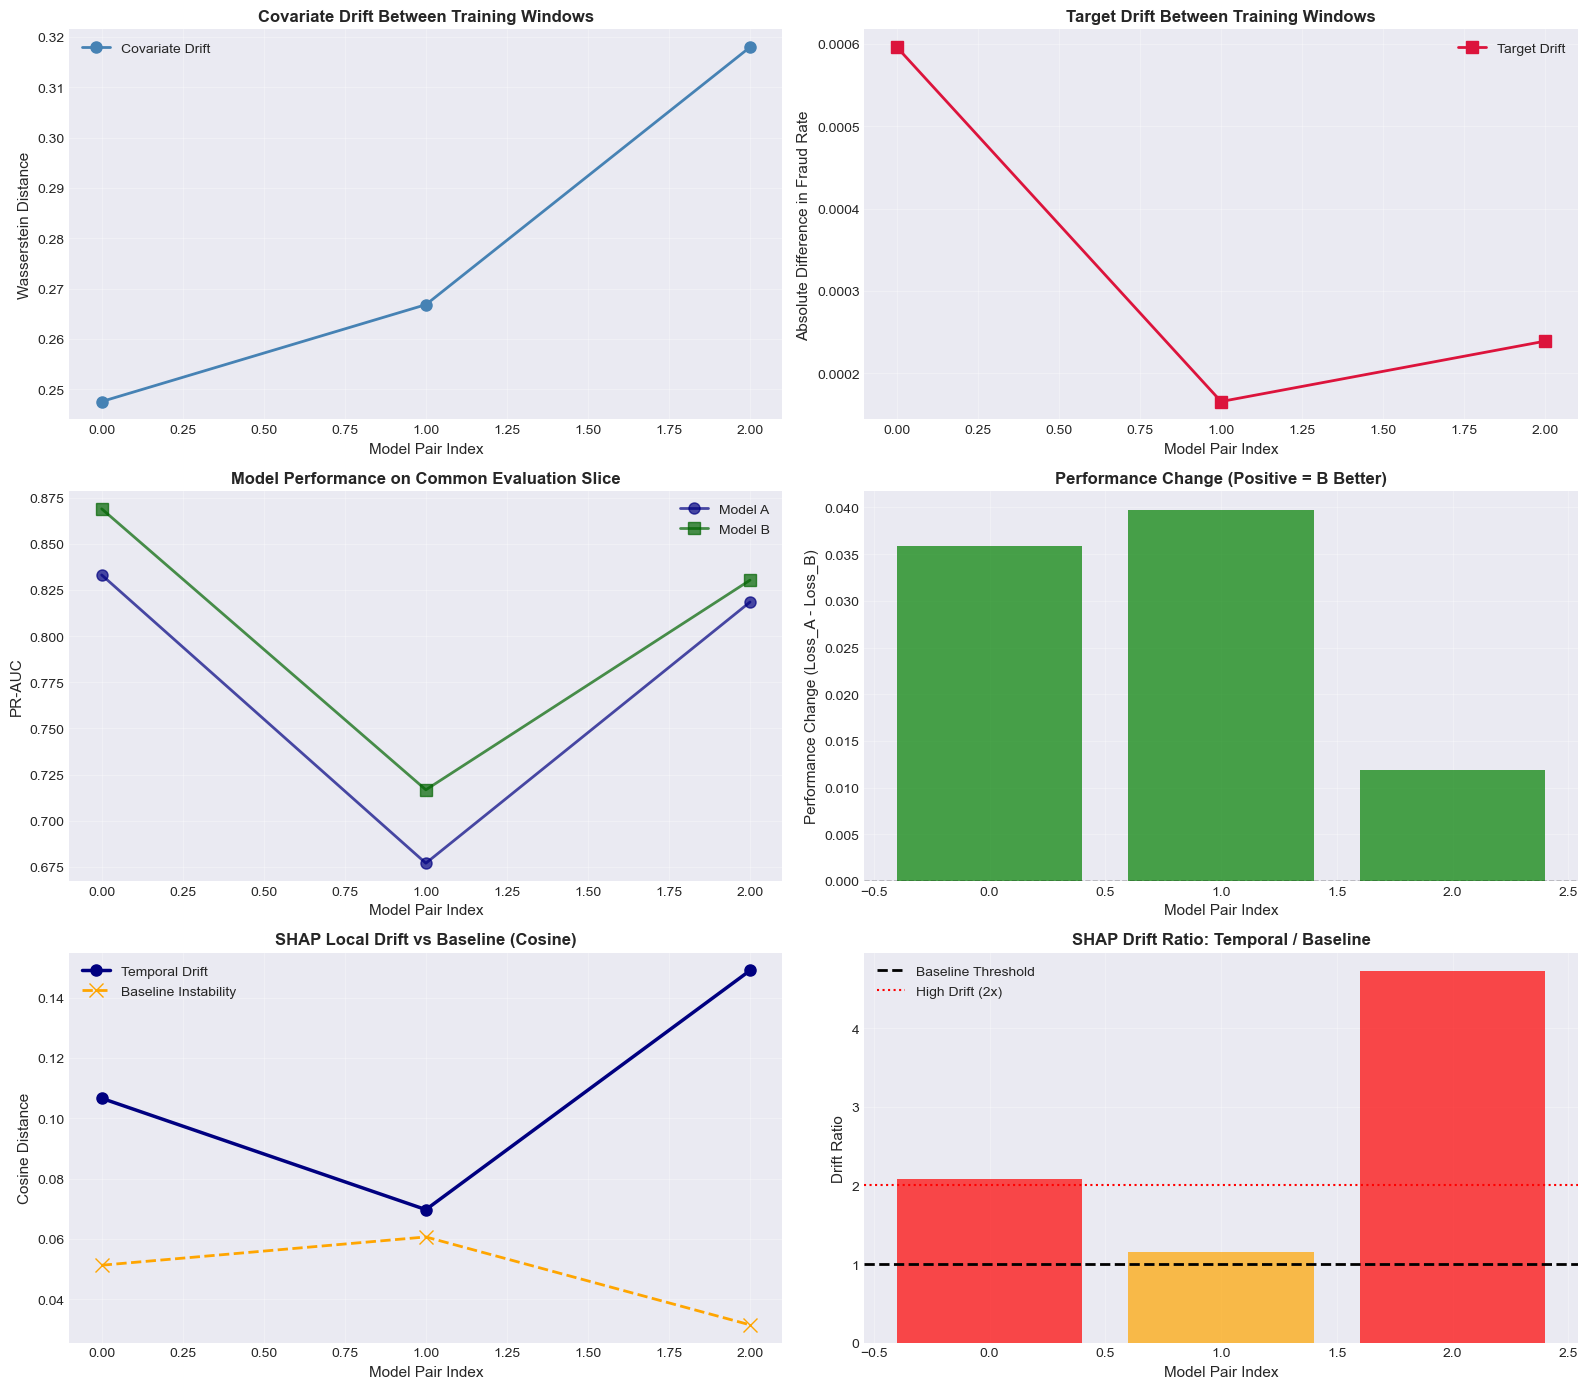

In [61]:
# Visualizations
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# 1. Data Drift over Time
axes[0, 0].plot(results_df['pair_idx'], results_df['covariate_drift'], 
                marker='o', linewidth=2, markersize=8, label='Covariate Drift', color='steelblue')
axes[0, 0].set_xlabel('Model Pair Index', fontsize=11)
axes[0, 0].set_ylabel('Wasserstein Distance', fontsize=11)
axes[0, 0].set_title('Covariate Drift Between Training Windows', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(results_df['pair_idx'], results_df['target_drift'], 
                marker='s', linewidth=2, markersize=8, color='crimson', label='Target Drift')
axes[0, 1].set_xlabel('Model Pair Index', fontsize=11)
axes[0, 1].set_ylabel('Absolute Difference in Fraud Rate', fontsize=11)
axes[0, 1].set_title('Target Drift Between Training Windows', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# 2. Performance Comparison
axes[1, 0].plot(results_df['pair_idx'], results_df['pr_auc_a'], 
                marker='o', linewidth=2, markersize=8, label='Model A', alpha=0.7, color='navy')
axes[1, 0].plot(results_df['pair_idx'], results_df['pr_auc_b'], 
                marker='s', linewidth=2, markersize=8, label='Model B', alpha=0.7, color='darkgreen')
axes[1, 0].set_xlabel('Model Pair Index', fontsize=11)
axes[1, 0].set_ylabel('PR-AUC', fontsize=11)
axes[1, 0].set_title('Model Performance on Common Evaluation Slice', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].bar(results_df['pair_idx'], results_df['delta_perf'], 
               alpha=0.7, color=['green' if x > 0 else 'red' for x in results_df['delta_perf']])
axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1, 1].set_xlabel('Model Pair Index', fontsize=11)
axes[1, 1].set_ylabel('Performance Change (Loss_A - Loss_B)', fontsize=11)
axes[1, 1].set_title('Performance Change (Positive = B Better)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# 3. SHAP Explanation Drift
if 'shap_local_cos_drift' in results_df.columns:
    axes[2, 0].plot(results_df['pair_idx'], results_df['shap_local_cos_drift'], 
                    marker='o', linewidth=2.5, markersize=8, label='Temporal Drift', color='navy')
    axes[2, 0].plot(results_df['pair_idx'], results_df['shap_baseline_cos'], 
                    marker='x', linewidth=2, markersize=10, label='Baseline Instability', 
                    color='orange', linestyle='--')
    axes[2, 0].set_xlabel('Model Pair Index', fontsize=11)
    axes[2, 0].set_ylabel('Cosine Distance', fontsize=11)
    axes[2, 0].set_title('SHAP Local Drift vs Baseline (Cosine)', fontsize=12, fontweight='bold')
    axes[2, 0].grid(True, alpha=0.3)
    axes[2, 0].legend()
    
    # Add drift ratio bars with color coding
    colors = ['red' if x > 2 else 'orange' if x > 1 else 'green' 
              for x in results_df['shap_drift_ratio_cos']]
    axes[2, 1].bar(results_df['pair_idx'], results_df['shap_drift_ratio_cos'], 
                   alpha=0.7, color=colors)
    axes[2, 1].axhline(y=1, color='black', linestyle='--', linewidth=2, label='Baseline Threshold')
    axes[2, 1].axhline(y=2, color='red', linestyle=':', linewidth=1.5, label='High Drift (2x)')
    axes[2, 1].set_xlabel('Model Pair Index', fontsize=11)
    axes[2, 1].set_ylabel('Drift Ratio', fontsize=11)
    axes[2, 1].set_title('SHAP Drift Ratio: Temporal / Baseline', fontsize=12, fontweight='bold')
    axes[2, 1].grid(True, alpha=0.3)
    axes[2, 1].legend()
else:
    axes[2, 0].text(0.5, 0.5, 'SHAP analysis not performed', 
                    ha='center', va='center', transform=axes[2, 0].transAxes, fontsize=12)
    axes[2, 1].text(0.5, 0.5, 'SHAP analysis not performed', 
                    ha='center', va='center', transform=axes[2, 1].transAxes, fontsize=12)

plt.tight_layout()
plt.show()

## 12. Interpretation and Contextualization

This section provides interpretation of the drift ratios in context with data drift and performance changes.

In [62]:
# Contextualized interpretation
print("="*80)
print("CONTEXTUALIZED INTERPRETATION OF DRIFT RATIOS")
print("="*80)

if 'shap_drift_ratio_cos' in results_df.columns:
    for idx, row in results_df.iterrows():
        print(f"\n{'─'*80}")
        print(f"📊 Model Pair {row['pair_idx']}:")
        print(f"{'─'*80}")
        print(f"  Time Windows:")
        print(f"    • Model A: ends at t={row['window_a_end']}")
        print(f"    • Model B: ends at t={row['window_b_end']}")
        
        print(f"\n  Fraud Detection:")
        print(f"    • Evaluation size: {row['eval_size']} transactions")
        print(f"    • Flagged for review: {row['num_flagged']} ({row['pct_flagged']:.2f}%)")
        
        print(f"\n  Data Context:")
        print(f"    • Covariate Drift: {row['covariate_drift']:.4f}")
        print(f"    • Target Drift: {row['target_drift']:.4f}")
        print(f"    • Performance Change: {row['delta_perf']:.4f} ({'✓ B better' if row['delta_perf'] > 0 else '⚠ A better'})")
        
        print(f"\n  Explanation Drift (Fraud-Flagged Transactions):")
        print(f"    • SHAP Drift Ratio (Cosine): {row['shap_drift_ratio_cos']:.2f}")
        print(f"    • SHAP Drift Ratio (RBO): {row['shap_drift_ratio_rbo']:.2f}")
        print(f"    • SHAP Global Drift: {row['shap_global_drift']:.4f}")
        print(f"    • Sign Flip Fraction: {row['shap_sign_flip_median']:.4f}")
        
        # Interpretation
        drift_ratio = row['shap_drift_ratio_cos']
        perf_change = row['delta_perf']
        cov_drift = row['covariate_drift']
        
        print(f"\n  💡 Interpretation:")
        if drift_ratio > 2:
            print(f"    ⚠️  HIGH explanation drift (>{2}x baseline)")
            if perf_change > 0.01 and cov_drift > 0.1:
                print(f"    ✓  Justified by substantial data drift and performance improvement")
                print(f"       → Model adapted to changing fraud patterns")
            else:
                print(f"    ⚠️  NOT clearly justified by data/performance changes")
                print(f"       → Potential explanation method instability or modeling artifacts")
        elif drift_ratio > 1:
            print(f"    ⚡ MODERATE explanation drift (>1x baseline)")
            print(f"       → Temporal drift exceeds random variation")
            if perf_change > 0:
                print(f"       → Consistent with model improvement on new data")
        else:
            print(f"    ✓  LOW explanation drift (<1x baseline)")
            print(f"       → Changes comparable to random variation")
            print(f"       → Explanations are relatively stable")

print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)
print("""
📌 FRAMEWORK IMPLEMENTATION:
   ✓ Feature standardization ensures comparable explanations
   ✓ TimeSeriesSplit CV prevents temporal leakage in hyperparameter tuning
   ✓ Fraud-flagged transactions only (realistic investigator workflow)
   ✓ Multiple replicas quantify baseline instability from training randomness

📊 DRIFT RATIO INTERPRETATION:
   • Ratio > 2: High temporal drift - investigate if justified by data/performance
   • Ratio 1-2: Moderate drift - exceeds baseline but may be expected
   • Ratio < 1: Low drift - changes within random variation bounds

🔍 CONTEXTUALIZATION IS CRUCIAL:
   High drift + High data drift + Performance improvement = Expected adaptation
   High drift + Low data drift + No performance change = Potential instability

📈 MULTIPLE METRICS PROVIDE COMPLETE PICTURE:
   • Cosine distance: Full vector alignment
   • RBO: Top-feature ranking stability (investigator-focused)
   • Sign flips: Directional changes in important features
   • Global drift: Overall feature importance shifts
""")

CONTEXTUALIZED INTERPRETATION OF DRIFT RATIOS

────────────────────────────────────────────────────────────────────────────────
📊 Model Pair 0:
────────────────────────────────────────────────────────────────────────────────
  Time Windows:
    • Model A: ends at t=2
    • Model B: ends at t=3

  Fraud Detection:
    • Evaluation size: 11594 transactions
    • Flagged for review: 81 (0.70%)

  Data Context:
    • Covariate Drift: 0.2476
    • Target Drift: 0.0006
    • Performance Change: 0.0358 (✓ B better)

  Explanation Drift (Fraud-Flagged Transactions):
    • SHAP Drift Ratio (Cosine): 2.08
    • SHAP Drift Ratio (RBO): 1.37
    • SHAP Global Drift: 0.3271
    • Sign Flip Fraction: 0.0000

  💡 Interpretation:
    ⚠️  HIGH explanation drift (>2x baseline)
    ✓  Justified by substantial data drift and performance improvement
       → Model adapted to changing fraud patterns

────────────────────────────────────────────────────────────────────────────────
📊 Model Pair 1:
───────────

## 13. Save Results

Save the results to CSV for further analysis.

In [ ]:
# Save results to CSV
output_filename = 'temporal_stability_results.csv'
results_df.to_csv(output_filename, index=False)
print(f"✓ Results saved to: {output_filename}")

# Also save configuration for reproducibility
config_info = {
    'time_step_hours': TIME_STEP_HOURS,
    'window_length': WINDOW_LENGTH,
    'retrain_step': RETRAIN_STEP,
    'eval_horizon': EVAL_HORIZON,
    'num_replicas': NUM_REPLICAS,
    'num_features': len(feature_cols),
    'num_pairs_evaluated': len(results_df),
    'feature_standardization': 'Yes (StandardScaler per training window)',
    'hyperparameter_tuning': 'Yes (TimeSeriesSplit CV with GridSearchCV)',
    'explanation_scope': 'Fraud-flagged transactions only',
    'fraud_threshold': 0.5
}

import json
with open('experiment_config.json', 'w') as f:
    json.dump(config_info, f, indent=2)
print(f"✓ Configuration saved to: experiment_config.json")

print("\n" + "="*80)
print("ALL RESULTS SAVED SUCCESSFULLY")
print("="*80)

In [ ]:
# Load dataset
df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded successfully. Shape: {df.shape}")

# Basic check
df.head()

Dataset loaded successfully. Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
